Load Library & Dataset

In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "/kaggle/input/datasets/maharshipandya/-spotify-tracks-dataset")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] "dataset.csv"

In [2]:
df <- read.csv("/kaggle/input/datasets/maharshipandya/-spotify-tracks-dataset/dataset.csv")

Data Understanding

In [3]:
glimpse(df)

Rows: 114,000
Columns: 21
$ X                <int> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,…
$ track_id         <chr> "5SuOikwiRyPMVoIQDJUgSV", "4qPNDBW1i3p13qLCt0Ki3A", "…
$ artists          <chr> "Gen Hoshino", "Ben Woodward", "Ingrid Michaelson;ZAY…
$ album_name       <chr> "Comedy", "Ghost (Acoustic)", "To Begin Again", "Craz…
$ track_name       <chr> "Comedy", "Ghost - Acoustic", "To Begin Again", "Can'…
$ popularity       <int> 73, 55, 57, 71, 82, 58, 74, 80, 74, 56, 74, 69, 52, 6…
$ duration_ms      <int> 230666, 149610, 210826, 201933, 198853, 214240, 22940…
$ explicit         <chr> "False", "False", "False", "False", "False", "False",…
$ danceability     <dbl> 0.676, 0.420, 0.438, 0.266, 0.618, 0.688, 0.407, 0.70…
$ energy           <dbl> 0.4610, 0.1660, 0.3590, 0.0596, 0.4430, 0.4810, 0.147…
$ key              <int> 1, 1, 0, 0, 2, 6, 2, 11, 0, 1, 8, 4, 7, 3, 2, 4, 2, 1…
$ loudness         <dbl> -6.746, -17.235, -9.734, -18.515, -9.681, -8.807, -8.…
$ mode        

In [4]:
head(df)

,X,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,⋯,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
1,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,⋯,-6.746,0,0.1430,0.0322,1.01e-06,0.3580,0.715,87.917,4,acoustic
2,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,⋯,-17.235,1,0.0763,0.9240,5.56e-06,0.1010,0.267,77.489,4,acoustic
3,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,⋯,-9.734,1,0.0557,0.2100,0.00e+00,0.1170,0.120,76.332,4,acoustic
4,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Soundtrack),Can't Help Falling In Love,71,201933,False,0.266,0.0596,⋯,-18.515,1,0.0363,0.9050,7.07e-05,0.1320,0.143,181.740,3,acoustic
5,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,⋯,-9.681,1,0.0526,0.4690,0.00e+00,0.0829,0.167,119.949,4,acoustic
6,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,⋯,-8.807,1,0.1050,0.2890,0.00e+00,0.1890,0.666,98.017,4,acoustic


Data Cleaning

In [5]:
df <- df %>%
  select(
    track_name, artists, track_genre, popularity,
    energy, valence, tempo,
    danceability, loudness, acousticness, speechiness
  )

In [6]:
sum(is.na(df))

[1] 0

In [7]:
df <- na.omit(df)

Distribusi Popularity

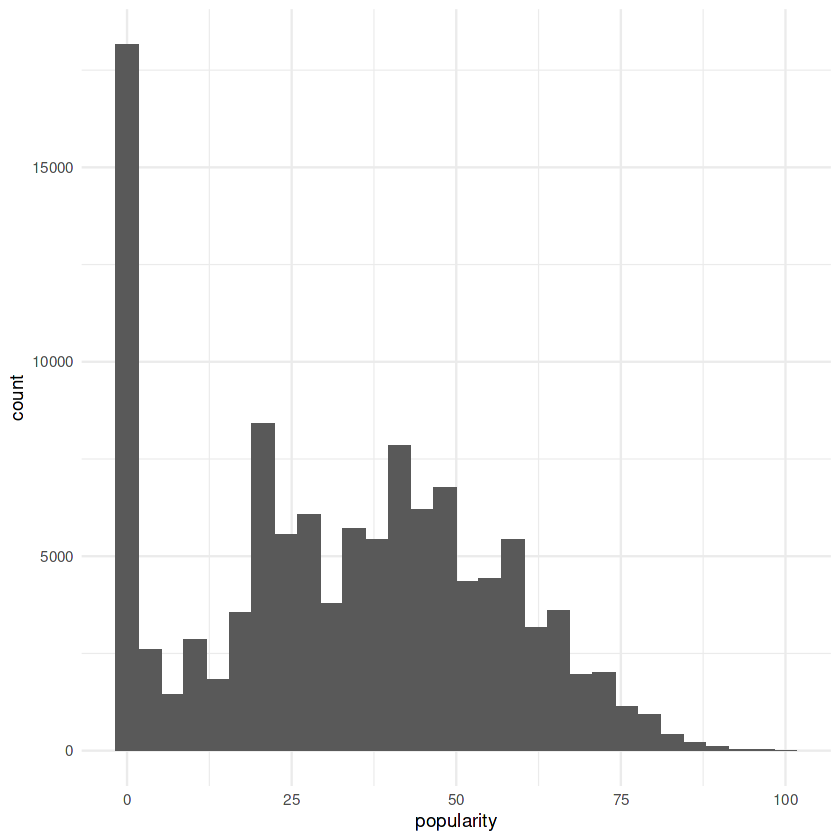

In [8]:
ggplot(df, aes(x = popularity)) +
  geom_histogram(bins = 30) +
  theme_minimal()

Core Feature Analysis

Energy

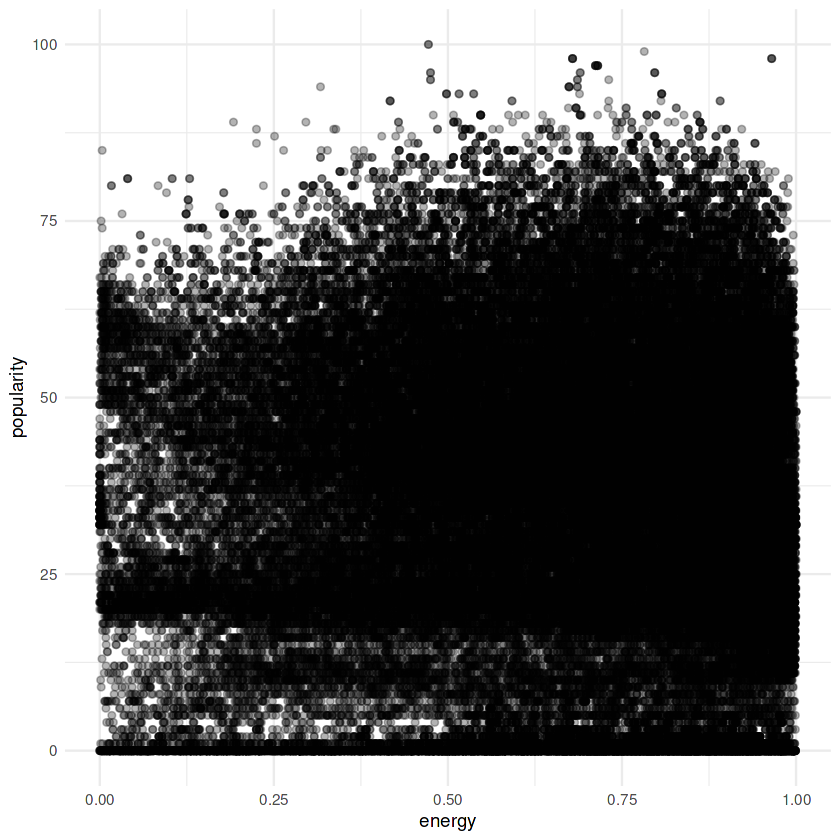

In [9]:
ggplot(df, aes(x = energy, y = popularity)) +
  geom_point(alpha = 0.3) +
  theme_minimal()

Valence

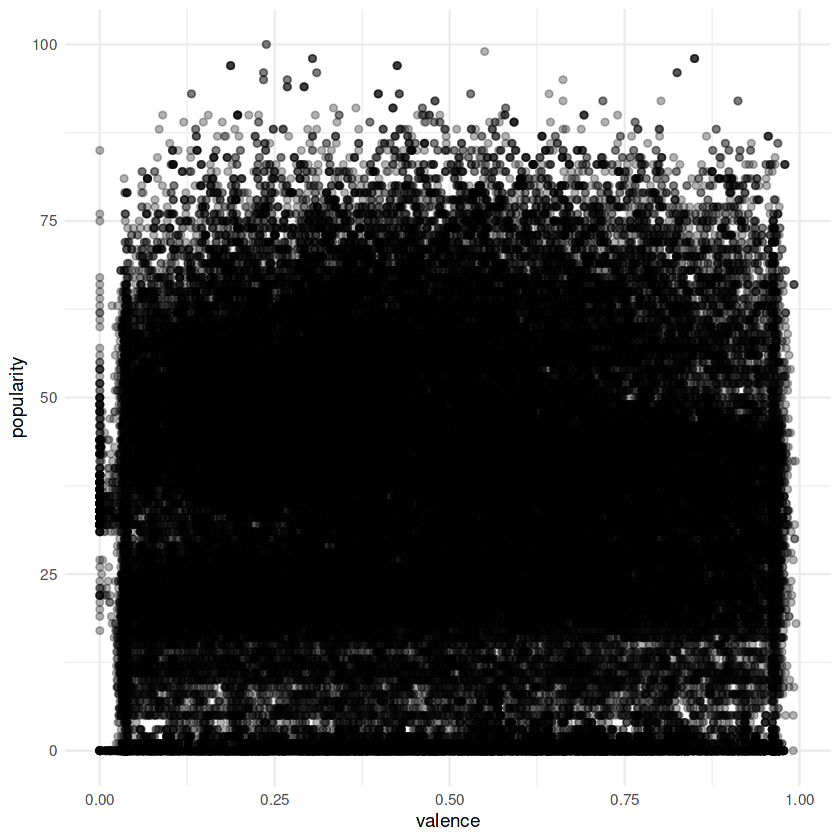

In [10]:
ggplot(df, aes(x = valence, y = popularity)) +
  geom_point(alpha = 0.3) +
  theme_minimal()

Danceability

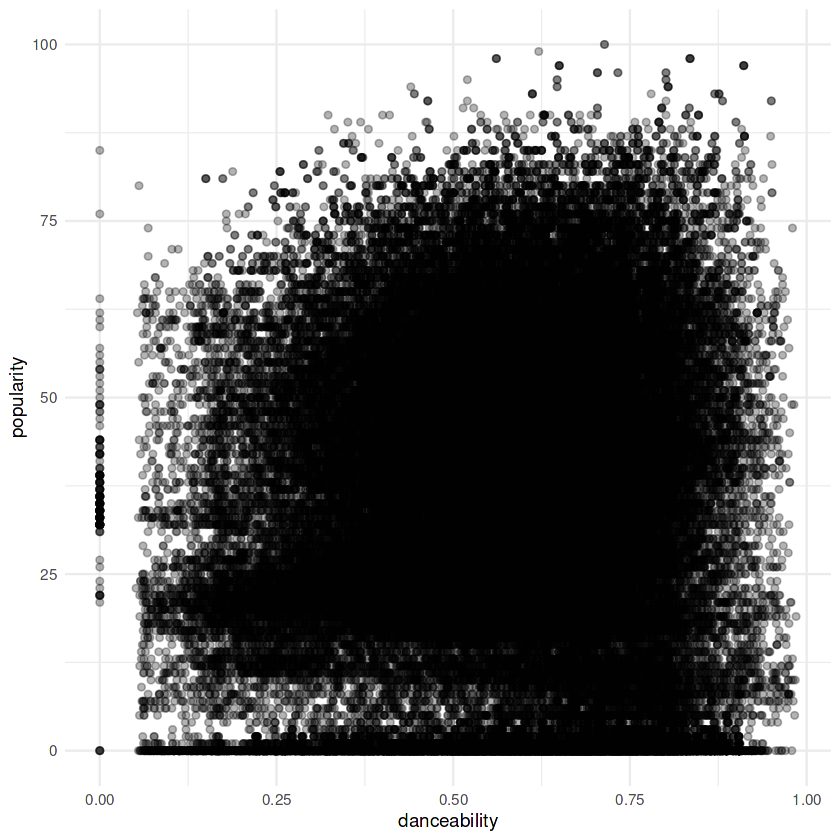

In [11]:
ggplot(df, aes(x = danceability, y = popularity)) +
  geom_point(alpha = 0.3) +
  theme_minimal()

Loudness

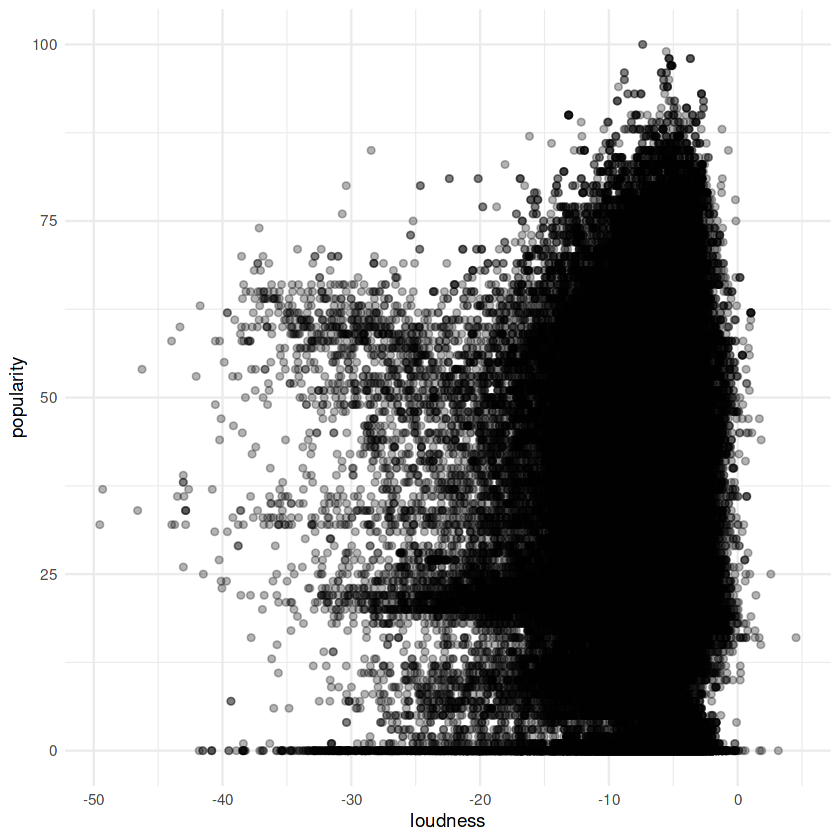

In [12]:
ggplot(df, aes(x = loudness, y = popularity)) +
  geom_point(alpha = 0.3) +
  theme_minimal()

Speechiness

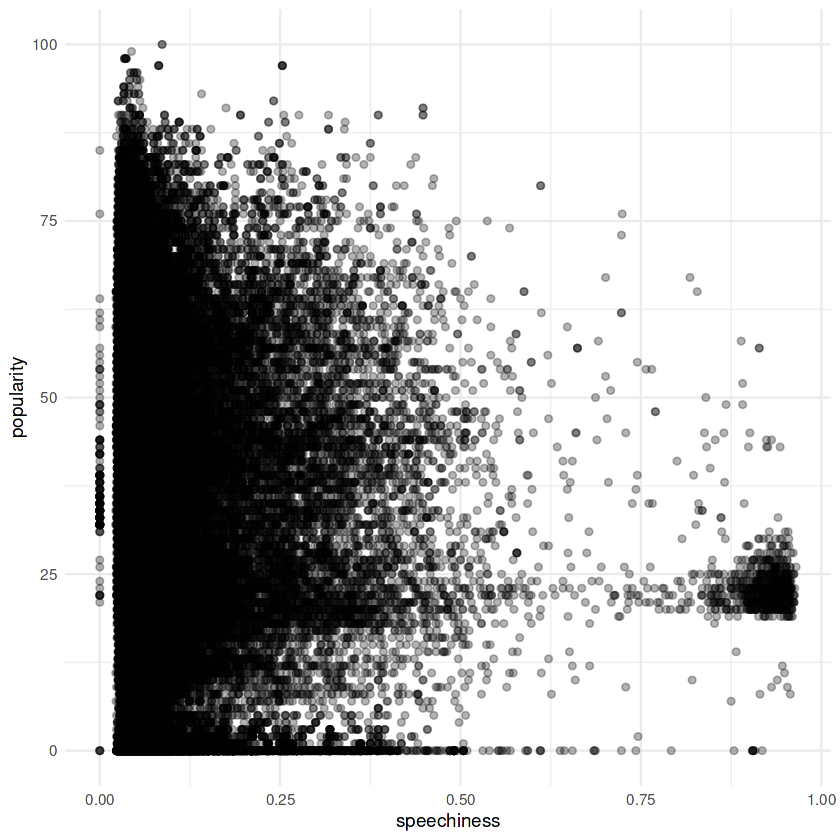

In [13]:
ggplot(df, aes(x = speechiness, y = popularity)) +
  geom_point(alpha = 0.3) +
  theme_minimal()

Create Popularity Category

In [14]:
df <- df %>%
  mutate(high_popularity = ifelse(popularity > 70, "High", "Low"))

Compare Features

In [15]:
df %>%
  group_by(high_popularity) %>%
  summarise(
    avg_energy = mean(energy),
    avg_valence = mean(valence),
    avg_danceability = mean(danceability),
    avg_loudness = mean(loudness),
    avg_acousticness = mean(acousticness)
  )

high_popularity,avg_energy,avg_valence,avg_danceability,avg_loudness,avg_acousticness
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
High,0.6745592,0.5051099,0.6186364,-6.560883,0.2166037
Low,0.6399099,0.4726901,0.5644987,-8.334348,0.3192745


Boxplot Comparison

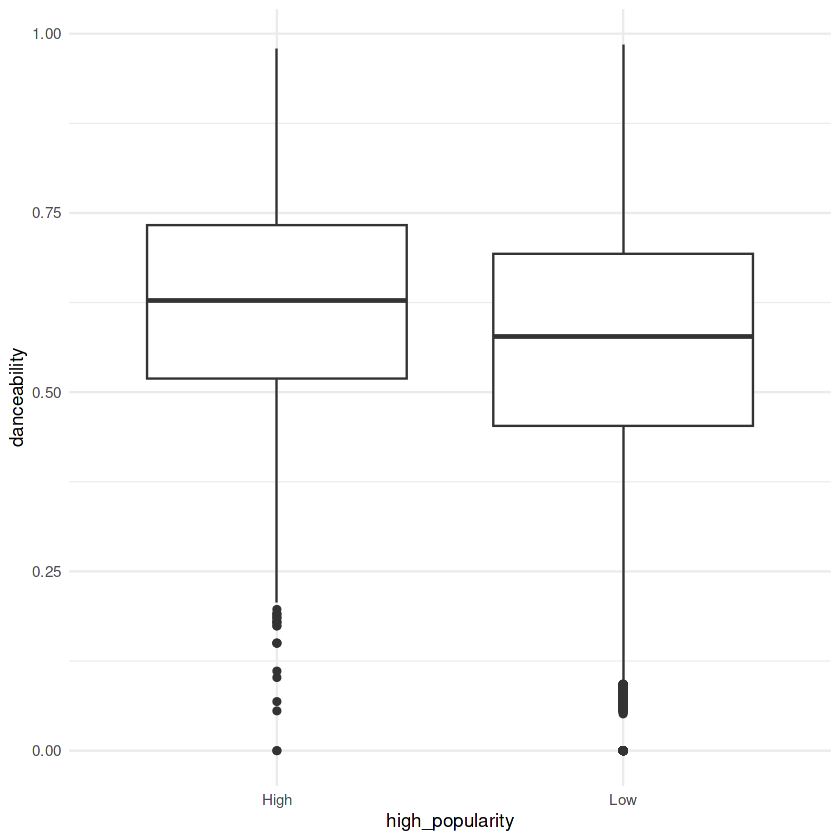

In [16]:
ggplot(df, aes(x = high_popularity, y = danceability)) +
  geom_boxplot() +
  theme_minimal()

Mood Classification

In [17]:
df <- df %>%
  mutate(
    mood = case_when(
      valence >= 0.6 & energy >= 0.6 ~ "Happy",
      valence < 0.4 & energy < 0.4 ~ "Sad",
      TRUE ~ "Neutral"
    )
  )

Mood vs Popularity

In [18]:
df %>%
  group_by(mood) %>%
  summarise(avg_popularity = mean(popularity)) %>%
  arrange(desc(avg_popularity))

mood,avg_popularity
<chr>,<dbl>
Neutral,34.09263
Sad,31.90455
Happy,31.81993


Mood Visualization

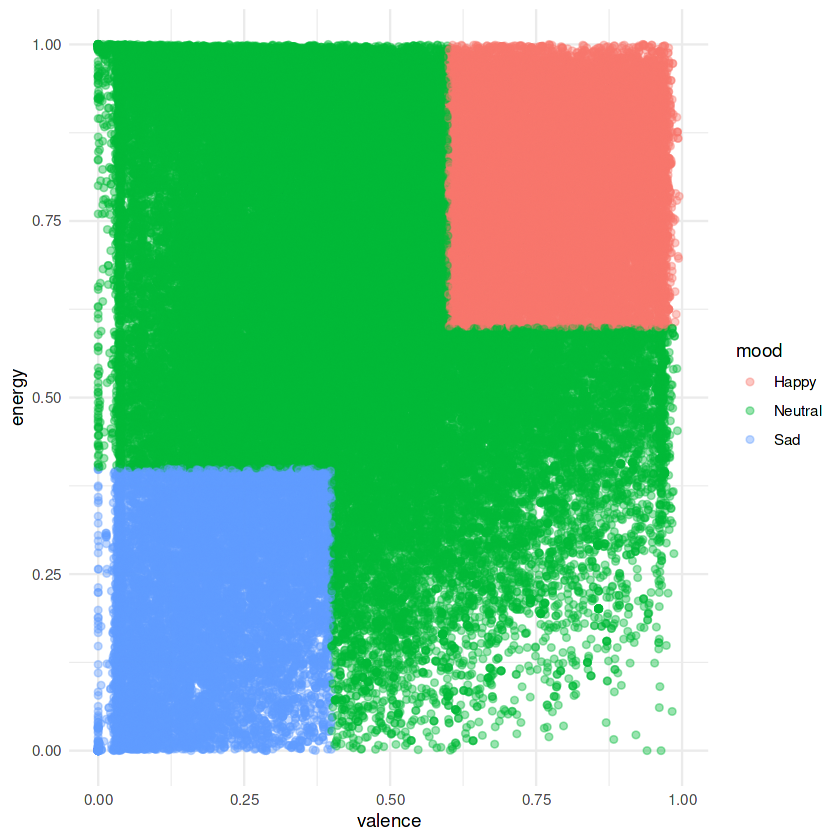

In [19]:
ggplot(df, aes(x = valence, y = energy, color = mood)) +
  geom_point(alpha = 0.4) +
  theme_minimal()

GENRE ANALYSIS

In [20]:
df %>%
  group_by(track_genre) %>%
  summarise(avg_popularity = mean(popularity)) %>%
  arrange(desc(avg_popularity)) %>%
  head(10)

track_genre,avg_popularity
<chr>,<dbl>
pop-film,59.283
k-pop,56.896
chill,53.651
sad,52.379
grunge,49.594
indian,49.539
anime,48.772
emo,48.128
sertanejo,47.866


Genre Visualization

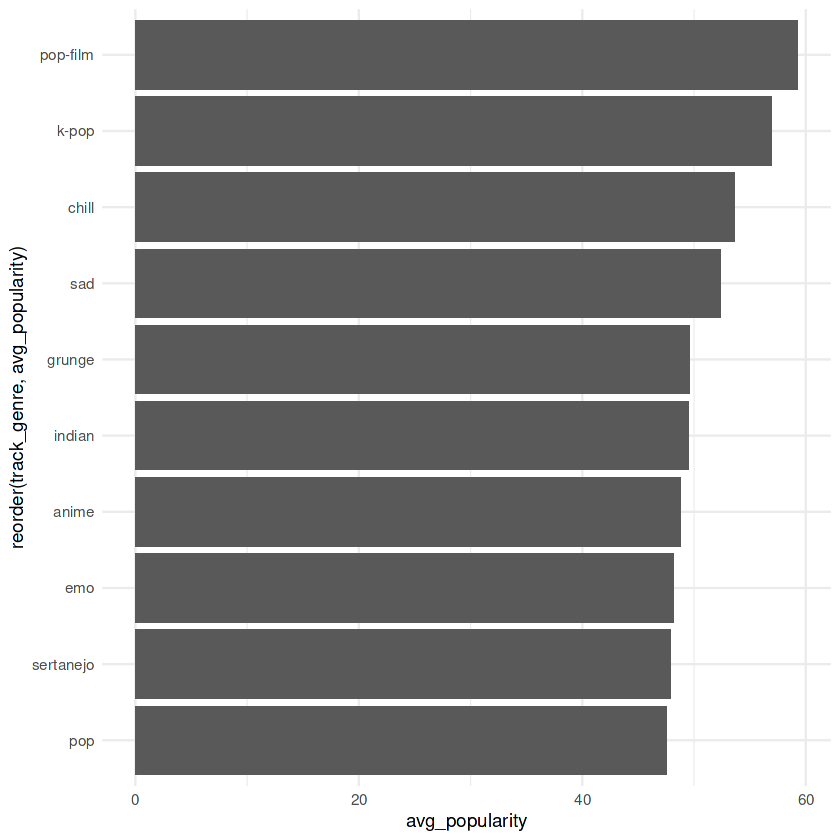

In [21]:
df %>%
  group_by(track_genre) %>%
  summarise(avg_popularity = mean(popularity)) %>%
  arrange(desc(avg_popularity)) %>%
  head(10) %>%
  ggplot(aes(x = reorder(track_genre, avg_popularity), y = avg_popularity)) +
  geom_col() +
  coord_flip() +
  theme_minimal()

Numeric Features Only

In [22]:
numeric_df <- df %>%
  select(
    popularity,
    danceability,
    energy,
    valence,
    loudness,
    acousticness,
    speechiness,
    tempo
  )

Correlation Matrix

In [23]:
cor(numeric_df)

,popularity,danceability,energy,valence,loudness,acousticness,speechiness,tempo
popularity,1.000000000,0.03544813,0.001056136,-0.04053429,0.05042304,-0.025472413,-0.044926549,0.01320466
danceability,0.035448135,1.00000000,0.134325483,0.47734124,0.25907673,-0.171533331,0.108626090,-0.05044987
energy,0.001056136,0.13432548,1.000000000,0.25893400,0.76168996,-0.733906321,0.142508868,0.24785051
valence,-0.040534295,0.47734124,0.258933995,1.00000000,0.27984788,-0.107070180,0.036634583,0.07827307
loudness,0.050423036,0.25907673,0.761689960,0.27984788,1.00000000,-0.589802667,0.060826328,0.21244590
acousticness,-0.025472413,-0.17153333,-0.733906321,-0.10707018,-0.58980267,1.000000000,-0.002186336,-0.20822415
speechiness,-0.044926549,0.10862609,0.142508868,0.03663458,0.06082633,-0.002186336,1.000000000,0.01727322
tempo,0.013204660,-0.05044987,0.247850510,0.07827307,0.21244590,-0.208224147,0.017273223,1.00000000


Heatmap Correlation

In [24]:
install.packages("corrplot")
library(corrplot)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



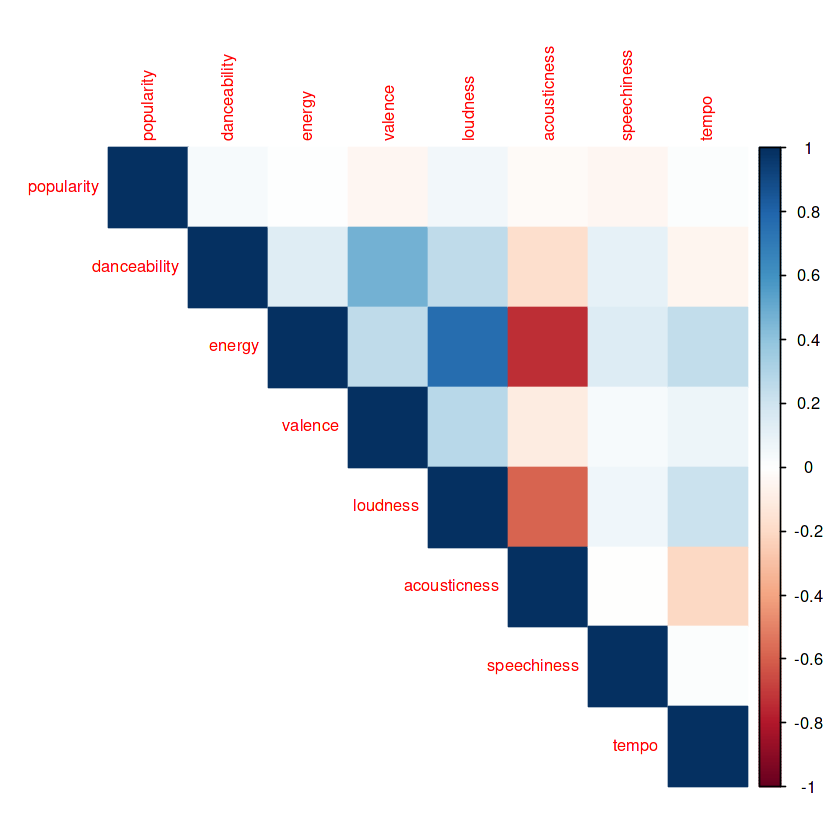

In [25]:
corr <- cor(numeric_df)

corrplot(
  corr,
  method = "color",
  type = "upper",
  tl.cex = 0.8
)

Ranking Faktor ke Popularity

In [26]:
correlation_popularity <- cor(numeric_df)[,"popularity"]

sort(correlation_popularity, decreasing = TRUE)

popularity     loudness danceability        tempo       energy acousticness 
 1.000000000  0.050423036  0.035448135  0.013204660  0.001056136 -0.025472413 
     valence  speechiness 
-0.040534295 -0.044926549

Visual Ranking

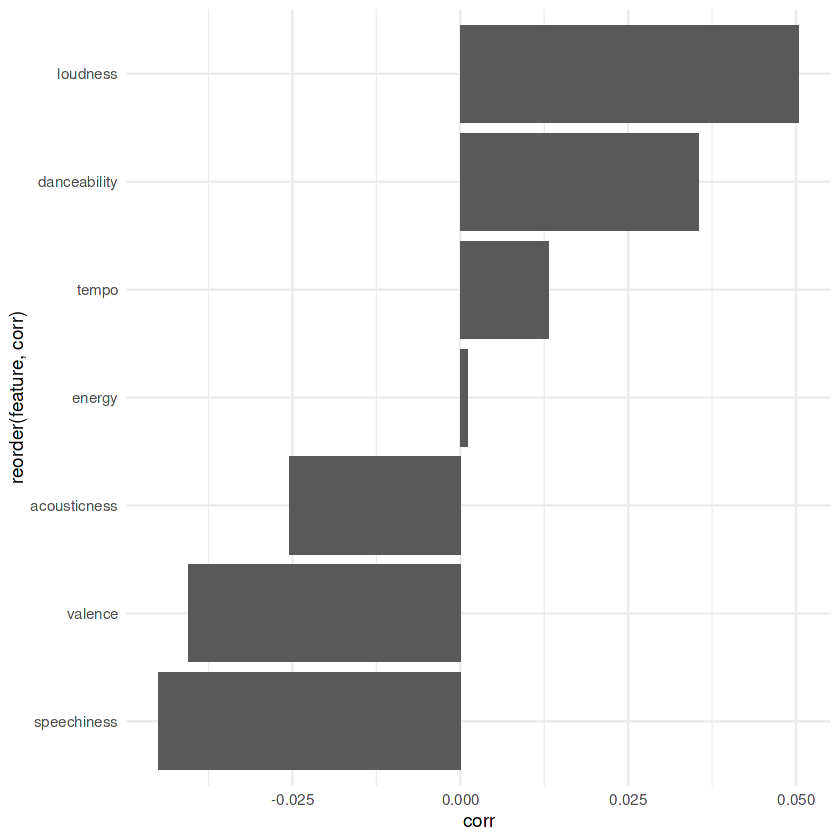

In [27]:
corr_df <- data.frame(
  feature = names(correlation_popularity),
  corr = as.numeric(correlation_popularity)
)

corr_df %>%
  filter(feature != "popularity") %>%
  ggplot(aes(x = reorder(feature, corr), y = corr)) +
  geom_col() +
  coord_flip() +
  theme_minimal()

High vs Low Popular Songs

In [28]:
df <- df %>%
 mutate(pop_group = ifelse(popularity >= 70, "High", "Low"))

Compare Means

In [29]:
df %>%
 group_by(pop_group) %>%
 summarise(
   danceability = mean(danceability),
   energy = mean(energy),
   loudness = mean(loudness),
   acousticness = mean(acousticness)
 )

pop_group,danceability,energy,loudness,acousticness
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
High,0.6160514,0.6710624,-6.663338,0.2211885
Low,0.5643168,0.6398863,-8.339412,0.3196355


Final Boxplot

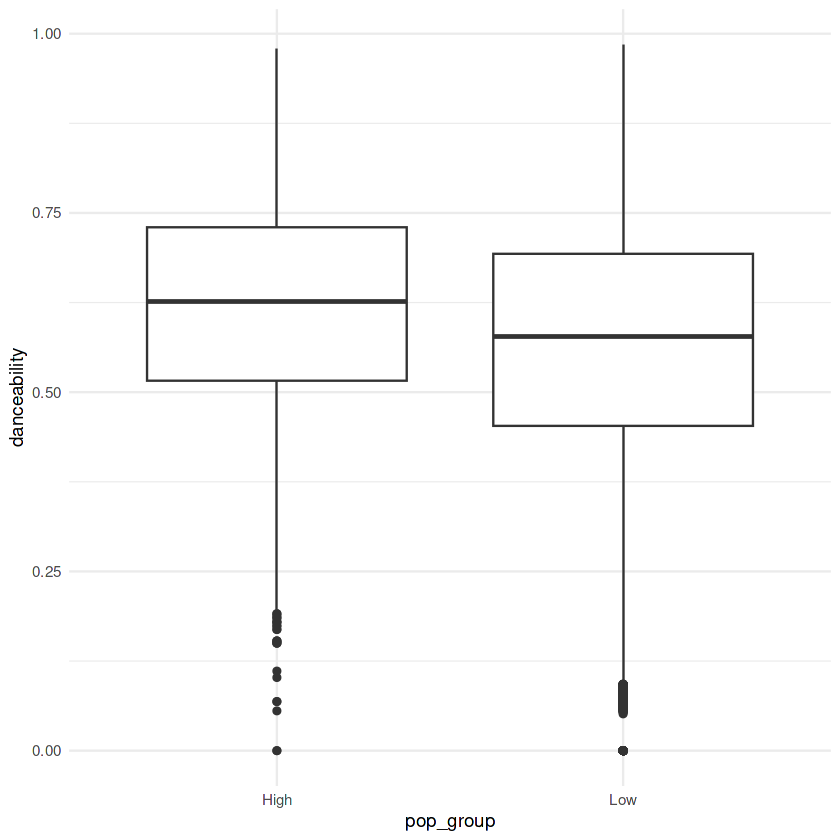

In [30]:
ggplot(df, aes(x = pop_group, y = danceability)) +
 geom_boxplot() +
 theme_minimal()

Create Target

In [31]:
df <- df %>%
 mutate(hit_song = ifelse(popularity >= 70, "Hit", "Not Hit"))

Select Features

In [32]:
model_df <- df %>%
 select(
   hit_song,
   danceability,
   energy,
   valence,
   loudness,
   acousticness,
   speechiness,
   tempo
 )

In [33]:
model_df$hit_song <- as.factor(model_df$hit_song)

In [34]:
set.seed(123)

sample_rows <- sample(1:nrow(model_df), 0.8*nrow(model_df))

train <- model_df[sample_rows, ]
test <- model_df[-sample_rows, ]

1st try model

In [40]:
install.packages("randomForest")
library(randomForest)

rf_model1 <- randomForest(
  hit_song ~ .,
  data = train,
  ntree = 100
)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [41]:
pred1 <- predict(rf_model1, test)

In [42]:
mean(pred1 == test$hit_song)

[1] 0.9770614

In [43]:
table(Predicted1 = pred1, Actual = test$hit_song)

          Actual
Predicted1   Hit Not Hit
   Hit       628      52
   Not Hit   471   21649

2nd try model

In [44]:
install.packages("randomForest")
library(randomForest)

rf_model <- randomForest(
  hit_song ~ .,
  data = train,
  ntree = 300,
  classwt = c(Hit = 3, "Not Hit" = 1)
)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [45]:
pred <- predict(rf_model, test)

In [46]:
mean(pred == test$hit_song)

[1] 0.9663158

In [47]:
table(Predicted = pred, Actual = test$hit_song)

         Actual
Predicted   Hit Not Hit
  Hit       694     363
  Not Hit   405   21338

,MeanDecreaseGini
danceability,4379.736
energy,5221.161
valence,4945.411
loudness,5089.726
acousticness,5300.366
speechiness,4371.579
tempo,4340.852


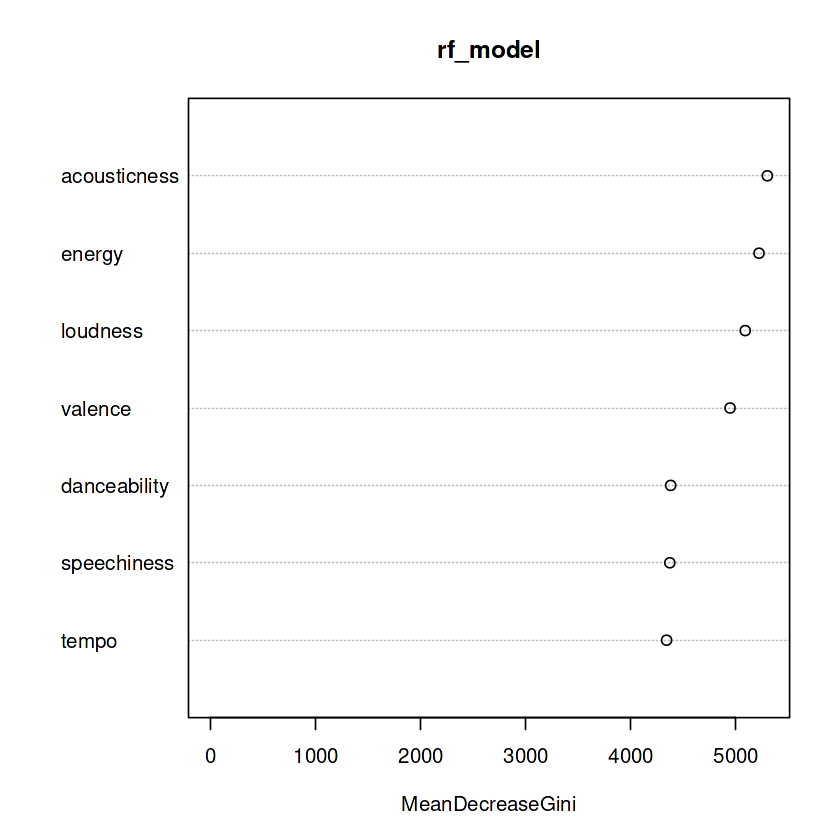

In [48]:
importance(rf_model)
varImpPlot(rf_model)